<a href="https://colab.research.google.com/github/rikharhm0208-coder/PROJECT_RIKHA/blob/main/Dinamika_Populasi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROJECT 1 DINAMIKA POPULASI**

Nama Anggota:
1. Ahmad Fani Sihombing (20124006)
2. Rikha Rahim (20124007)

# **Penyelesaian Sistem Persamaan Diferensial dan Bidang Fasa**

*Catatan: Sebagian materi ini merupakan bahan Praktikum PPD 2023*

Pada bagian ini kan dibahas mengenai sistem persamaan diferensial, khususnya sistem persamaan diferensial linier homogen. SPD linier homogen merupakan sistem persamaan diferensial dengan bentuk
\begin{align*}
f_1'(x) &= a_{11}f_1(x) + a_{12}f_2(x) + ... a_{1n}f_n(x)\\
f_2'(x) &= a_{21}f_1(x) + a_{22}f_2(x) + ... a_{2n}f_n(x)\\
&\vdots \\
f_n'(x) &= a_{n1}f_1(x) + a_{n2}f_2(x) + ... a_{nn}f_n(x)\\
\end{align*}

yang dapat dituliskan sebagai:
\begin{equation*}
\textbf{F}'=A\textbf{F}
\end{equation*}
dimana $\textbf{F}=\begin{bmatrix}f_1 \\ f_2 \\\vdots \\f_n\end{bmatrix}$ dan  $A=\begin{bmatrix} a_{11} & a_{12} & ... & a_{n1}\\ \vdots &   \ddots      &      & \vdots \\a_{n1} &   a_{n2}     &    ...   & a_{nn}\end{bmatrix}$

> **Contoh 1:**
\begin{align*}
\dfrac{dx}{dt} &= 2x-3y\\
\dfrac{dy}{dt} &= 22x +71y
\end{align*}
merupakan sistem persamaan diferensial linear yang homogen.

> **Contoh 2:**
\begin{align*}
\dfrac{dx}{dt} &= 2x-3y\\
\dfrac{dy}{dt} &= 22x +71y + \sin(t)
\end{align*}
merupakan sistem persamaan diferensial linear yang **tidak homogen**.

> **Contoh 3:**
\begin{align*}
\dfrac{dx}{dt} &= 2x-3xy\\
\dfrac{dy}{dt} &= 22x +71y
\end{align*}
merupakan sistem persamaan diferensial **nonlinear** yang homogen.

> **Contoh 4:**
\begin{align*}
\dfrac{dx}{dt} &= 2x-3xy\\
\dfrac{dy}{dt} &= 22x +71y +\sin(t)
\end{align*}
merupakan sistem persamaan diferensial **nonlinear** dan **tidak homogen.**

## ***Mencari Solusi SPD dengan `dsolve`***

Pandang SPD linier sebagai berikut.
\begin{align*}
\dfrac{dx}{dt} &= x+4y\\
\dfrac{dy}{dt} &= 3x +y
\end{align*}

dengan kondisi nilai awal adalah $x(0)=1$ dan $y(0)=0$


In [ ]:
import numpy as np
from sympy import solve, Eq, Derivative
from sympy import *
import sympy
import matplotlib.pyplot as plt
sympy.init_printing()
x, y = symbols("x y", cls=Function, Function=True) # Nyatakan x dan y sebagai handle fungsi
t, C1, C2 = symbols("t C1 C2") # Nyatakan t, C1, C2 sebagai simbol.

eq1 = Eq(Derivative(x(t), t), x(t) + 4*y(t))
eq2 = Eq(Derivative(y(t), t),3*x(t) + y(t))
soln = dsolve((eq1, eq2)) # output dari soln berupa suatu list.
print('Solusi Umum | Metode dsolve :')
soln


Solusi Umum | Metode dsolve :


⎡                  t⋅(1 - 2⋅√3)            t⋅(1 + 2⋅√3)                        ↪
⎢         2⋅√3⋅C₁⋅ℯ               2⋅√3⋅C₂⋅ℯ                         t⋅(1 - 2⋅√ ↪
⎢x(t) = - ───────────────────── + ─────────────────────, y(t) = C₁⋅ℯ           ↪
⎣                   3                       3                                  ↪

↪                      ⎤
↪ 3)       t⋅(1 + 2⋅√3)⎥
↪    + C₂⋅ℯ            ⎥
↪                      ⎦

In [ ]:
# Substitusi kondisi awal untuk memperoleh C1, C2
constants = solve((soln[0].subs(t, 0).subs(x(0), 0),
                soln[1].subs(t, 0).subs(y(0), 1)), {C1, C2})
# Solusi khusus x
sol_x = soln[0].rhs.subs(constants)
# Solusi khusus y
sol_y = soln[1].rhs.subs(constants)
print('Solusi Khusus (x(t), y(t)) | Metode dsolve : ')
sol_x, sol_y

Solusi Khusus (x(t), y(t)) | Metode dsolve : 


⎛      t⋅(1 - 2⋅√3)       t⋅(1 + 2⋅√3)   t⋅(1 - 2⋅√3)    t⋅(1 + 2⋅√3)⎞
⎜  √3⋅ℯ               √3⋅ℯ              ℯ               ℯ            ⎟
⎜- ──────────────── + ────────────────, ───────────── + ─────────────⎟
⎝         3                  3                2               2      ⎠

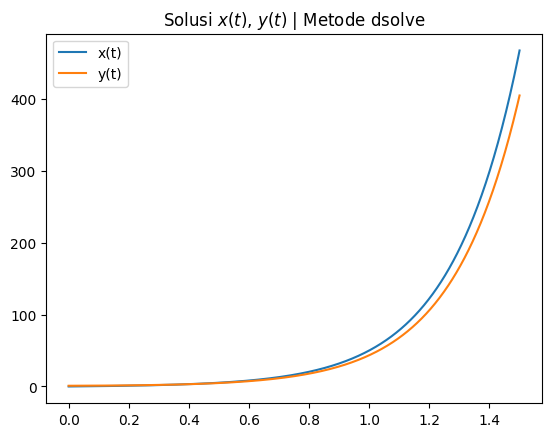

In [ ]:
# Plot solusi
plt.rcParams['figure.dpi'] = 100
func_x = lambdify(t, sol_x)
func_y = lambdify(t, sol_y)

t_s = np.linspace(0, 1.5, 1000)
plt.plot(t_s, func_x(t_s))
plt.plot(t_s, func_y(t_s))
plt.legend(['x(t)', 'y(t)'])
plt.title('Solusi $x(t)$, $y(t)$ | Metode dsolve')
plt.show()

## ***Plot Bidang Fasa***

**Bidang Fasa** (atau *phase portrait* atau potret fasa) adalah representasi geometri dari trajektori solusi (lintasan solusi) dari suatu sistem dinamik.

Dengan mengetahui bidang fasa dari suatu sistem diferensial, maka dinamika dari suatu solusi dengan nilai awal tertentu dapat diketahui.

*Catatan* : Untuk sistem persamaan diferensial, sumbu - sumbu dari bidang fasa adalah *state-variable* nya e.g $x(t)$ vs $y(t)$, bukan waktu $(t)$.

Untuk menggambar bidang fasa pada Python, kali ini kita akan memanfaatkan perintah `quiver` dari `matplotlib`. Perintah ini menghasilkan plot berisikan panah - panah.

`quiver(x, y, U, V)` menerima 4 input, yaitu

1. `x` dan `y` : vektor koordinat $x$ dan $y$ dari lokasi panah
2. `U` dan `V` : vektor arah dari panah


Akan ditampilkan bidang fasa dari sistem pada contoh diatas.


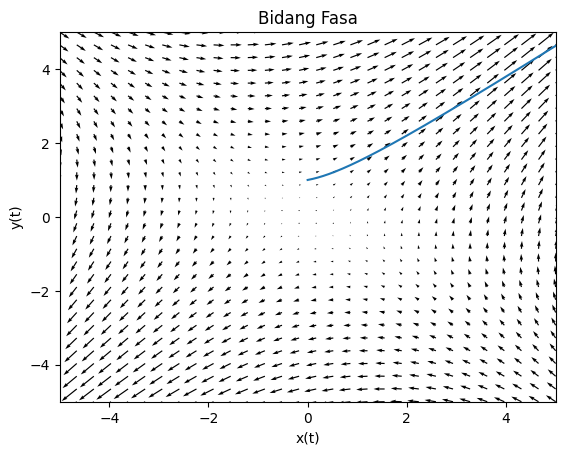

In [ ]:
func_x = lambdify(t, sol_x)
func_y = lambdify(t, sol_y)

t_s = np.linspace(0, 1.5, 1000)

# membuat vektor koordinat x dan y, menandakan lokasi panah
x_s = np.linspace(-5,5, 30)
y_s = np.linspace(-5,5, 30)
# gunakan np.meshgrid untuk menghasilkan matriks koordinat dari vektor koordinat x_s dan y_s
x_s, y_s = np.meshgrid(x_s, y_s)

plt.quiver(x_s, y_s, x_s+4*y_s, 3*x_s+y_s)
plt.plot(func_x(t_s), func_y(t_s)) # plot salah satu lintasan solusi
plt.xlabel('x(t)')
plt.ylabel('y(t)')
plt.xlim([-5, 5])
plt.ylim([-5, 5])
plt.title('Bidang Fasa')
plt.show()

## ***Solusi Numerik SPD dengan menggunakan odeint***

Sebelum melangkah lebih jauh, kalian akan berkenalan dengan perintah `odeint` dari paket `scipy.integrate` untuk menentukan solusi suatu persamaan diferensial secara numerik.

Pada praktikum sebelumnya, Anda sudah mempelajari cara menggunakan perintah `dsolve` untuk menentukan solusi dari persamaan diferensial linier, homogen ataupun non-homogen.

Pada Bagian ini, kita akan banyak menggambar bidang fasa, dengan bantuan `odeint`. Mengapa kita lebih memilih untuk menggunakan `odeint` dibandingkan `dsolve`?

1.   `dsolve` memberikan solusi SPD secara simbolik. Artinya, kita perlu mendefinisikan variabel - variabel simbolik seperti `t` atau `x`, `y`. Hasil keluaran yang diberikan tidak dapat langsung ditampilkan sebagai grafik.
2.    Perintah `odeint` memberikan aproksimasi numerik menggunakan metode Runge-Kutta 4. Keluaran yang dihasilkan merupakan suatu `array`, sehingga dapat langsung ditampilkan pada grafik tanpa perlu modifikasi lebih lanjut.

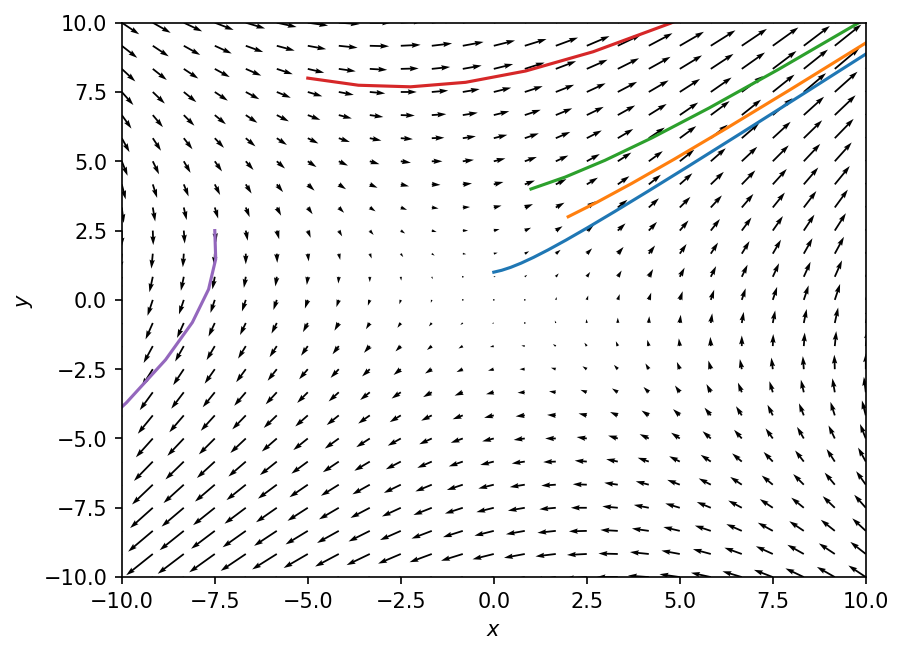

In [ ]:
import matplotlib.pyplot as plt
from scipy.integrate import odeint
plt.rcParams['figure.dpi'] = 150

# Domain bidang fasa
x_s = np.linspace(-10, 10, 25) # partisi selang [-10, 10] menjadi 25 titik (24 subselang)
y_s = np.linspace(-10, 10, 25)

x_grid, y_grid = np.meshgrid(x_s, y_s)

plt.quiver(x_grid, y_grid, x_grid+4*y_grid, 3*x_grid+y_grid)
plt.xlabel('$x$')
plt.ylabel('$y$')

# Gambar trajektori solusi
def model(U, t):
    x, y = U
    dxdt = x + 4*y
    dydt =  3*x + y
    return [dxdt, dydt]

inits = [[0, 1], [2, 3], [1, 4], [-5, 8], [-7.5, 2.5]]
for xy_i in inits:
    tspan = np.linspace(0, 10, 200)
    ys = odeint(model, xy_i, tspan)
    plt.plot(ys[:, 0], ys[:, 1])

plt.xlim([-10, 10])
plt.ylim([-10, 10])
plt.show()

## ***Sistem Nonlinier***

Salah satu model sistem non-linear yang paling sering dipelajari adalah model interaksi antara dua spesies. Akibat keberadaan suku nonlinear, umumnya titik ekuilibrium dari sistem berikut tidak hanya di titik asal $(0,0)$ saja.

Bentuk umum dari persamaan interaksi dua spesies adalah,
\begin{align*}
x' &= Ax + Bxy + Cx^2\\
y' &= Dy + Exy + Fy^2
\end{align*}
dengan $A,B,C,D,E,F$ suatu konstanta dan $x(t), y(t)$ menyatakan jumlah populasi dari spesies 1 dan spesies 2 berturu - turut.

> Contoh : Model interaksi mangsa-pemangsa (Lotka-Volterra) merupakan salah satu kasus khusus dari persamaan diatas, yang diberikan oleh
\begin{align*}
x' &= ax - bxy\\
y' &= dy + exy
\end{align*}

Jenis kestabilan dari semua titik kestabilan dapat ditentukan **secara lokal** dengan mengamati bidang fasa yang dibentuk.

> *Contoh 2*
Pandang sistem
\begin{align*}
\dfrac{dx}{dt} &=x - 0.5xy\\
\dfrac{dy}{dt} &=-3y+xy
\end{align*}



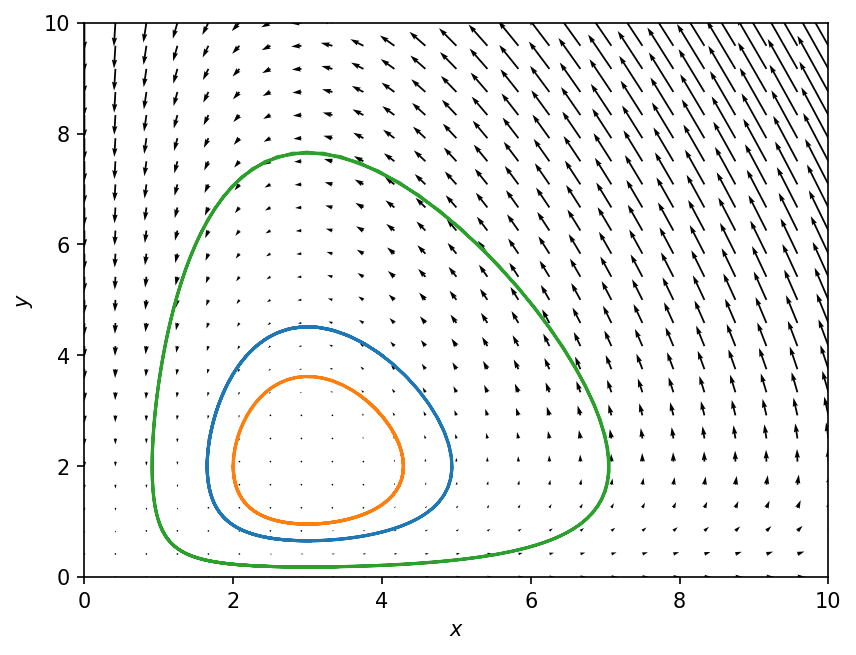

In [ ]:
import matplotlib.pyplot as plt
from scipy.integrate import odeint
plt.rcParams['figure.dpi'] = 150

# Domain bidang fasa
x_s = np.linspace(0, 10, 25) # partisi selang [0, 10] menjadi 25 titik (24 subselang)
y_s = np.linspace(0, 10, 25)

x_grid, y_grid = np.meshgrid(x_s, y_s)

plt.quiver(x_grid, y_grid, x_grid-0.5*x_grid*y_grid, -3*y_grid+x_grid*y_grid)
plt.xlabel('$x$')
plt.ylabel('$y$')

# Gambar trajektori solusi
def model(U, t):
    x, y = U
    dxdt = x -0.5*x*y
    dydt =  -3*y + x*y
    return [dxdt, dydt]

inits = [[4, 4], [2, 2], [1, 1]]
for xy_i in inits:
    tspan = np.linspace(0, 10, 200)
    ys = odeint(model, xy_i, tspan)
    plt.plot(ys[:, 0], ys[:, 1])

plt.xlim([0, 10])
plt.ylim([0, 10])
plt.show()

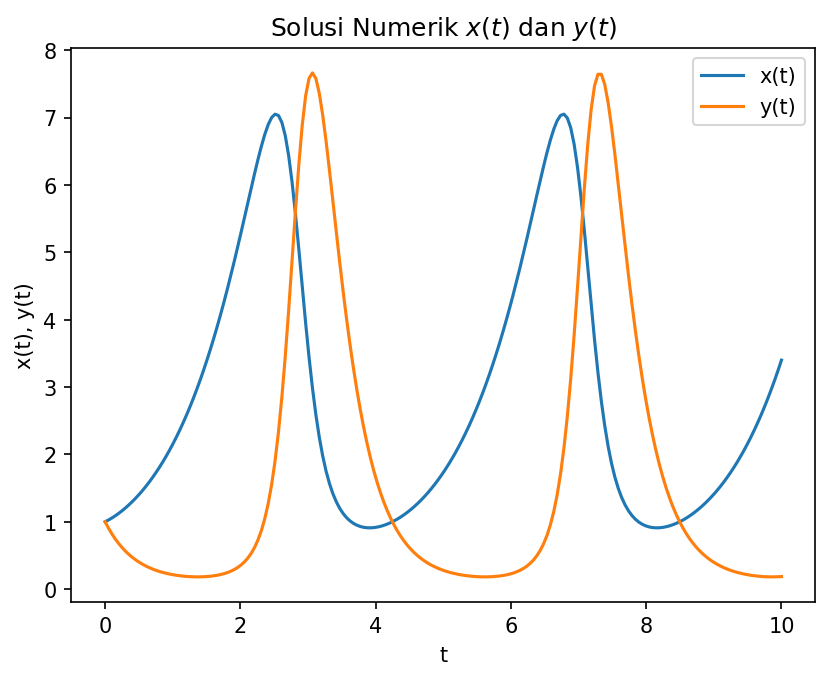

In [ ]:
#Plot solusi
tspan = np.linspace(0, 10, 200)
ys = odeint(model, [1, 1], tspan)
plt.plot(tspan, ys[:, 0])
plt.plot(tspan, ys[:, 1])
plt.title("Solusi Numerik $x(t)$ dan $y(t)$")
plt.xlabel("t")
plt.ylabel("x(t), y(t)")
plt.legend(['x(t)', 'y(t)'])


## ***Mencari Parameter dengan `minimize`***

In [ ]:
from scipy.optimize import minimize
# Kontruksi Data Sintetis
def true_model(U, t):
  x, y = U
  dxdt = x-0.5*x*y
  dydt = -3*y+x*y
  return [dxdt, dydt]
t_data = np.linspace(0, 10, 50)
init_cond = [1,1]
data_obs = odeint(true_model, init_cond, t_data)

Misalkan kita telah mengonstruksi model sistem persamaan diferensial sebagai berikut
\begin{align*}
x' &= x - bxy\\
y' &= dy + xy
\end{align*}

dengan kondisi awal $x(0)$ dan $y(0)$.

Selain itu, kita memiliki data deret waktu untuk $x$ dan $y$. Tugas kita adalah mengestimasi nilai b dan y sehingga model kita memiliki solusi yang dekat dengan dinamika aslinya.

In [ ]:
#Definisikan model
def model(U, t, b, d):
  x, y = U
  dxdt = x-b*x*y
  dydt = d*y+x*y
  return [dxdt, dydt]

#Definisikan fungsi objektif
def objective_function(params):
  b, d = params
  #Simulasikan model dengan parameter tebakan saat ini
  sim_guess = odeint(model, init_cond, t_data, args=(b, d))
  error = np.sum((data_obs - sim_guess)**2)
  return error

#Tebakan awal
init_guess = [1, -1]
result = minimize(objective_function, init_guess, method='Nelder-Mead')
b, d = result.x
print(f'Nilai b: {b}')
print(f'Nilai d: {d}')

Nilai b: 0.4999944169078362
Nilai d: -3.0000050585087195


# **TUGAS** - ***Pemodelan Kompetisi Vektor (Aedes aegypti vs Aedes albopictus)***

Perubahan iklim yang ekstrem telah banyak mengubah lanskap ekologi. Dua spesies nyamuk, yaitu Aedes aegypti dan Aedes albopictus, sering kali ditemukan bersaing memperebutkan habitat yang sama, seperti genangan air di ban bekas, pot tanaman, atau wadah penampungan air buatan manusia. Keduanya adalah vektor utama penular virus Dengue, Zika, dan Chikungunya. Namun, kemampuan mereka dalam menularkan penyakit (kompetensi vektor) dan preferensi mereka dalam menggigit manusia sangat berbeda. Oleh karena itu, mengetahui spesies mana yang akan "menang" dan mendominasi suatu lingkungan sangatlah krusial bagi dinas kesehatan dalam memitigasi risiko wabah. Keunggulan kompetitif kedua nyamuk ini sangat bergantung pada faktor lingkungan. Selain itu, kualitas sumber makanan di genangan air juga mengubah aturan main dari persaingan mereka.

# Model Matematika
Model yang digunakan pada fenomena ini adalah ODE berdasarkan fase hidup nyamuk. Model ini mengasumsikan bahwa masing-masing spesies dibagi menjadi fase **Juvenil (J)** (telur, larva, pupa) dan **Dewasa (A)**

Misalkan indeks $i=1$ mewakili populasi Ae. aegypti dan $i=2$ mewakili populasi Ae. albopictus. Dinamika populasinya dimodelkan sebagai berikut:

$$\begin{align}
\frac{dJ_1}{dt} &= f_1 A_1 (1 - \alpha_{11} J_1 - \alpha_{12} J_2) - d_1 J_1 \\
\frac{dA_1}{dt} &= d_1 J_1 - \mu_1 A_1 \\
\frac{dJ_2}{dt} &= f_2 A_2 (1 - \alpha_{22} J_2 - \alpha_{21} J_1) - d_2 J_2 \\
\frac{dA_2}{dt} &= d_2 J_2 - \mu_2 A_2
\end{align}$$

Keterangan:
*   $f_i$: Laju fekunditas (jumlah telur yang dihasilkan per nyamuk dewasa per hari)
*   $d_i$: Laju perkembangan (transisi dari fase juvenil menjadi nyamuk dewasa)
*   $\mu_i$: Laju kematian alami nyamuk dewasa.
*   $\alpha_{ii}$: Koefisien kompetisi intra-spesies (persaingan sesama jenis)
*   $\alpha_{ij}$: Koefisien kompetisi inter-spesies (persaingan memperebutkan makanan antar spesies yang berbeda)


Suku $(1 - \alpha_{ii} J_i - \alpha_{ij} J_j)$ merepresentasikan batas daya dukung lingkungan karena terbatasnya ruang dan nutrisi di genangan air.

# Bagian A
Suhu sangat memengaruhi laju bertelur ($f$) dan laju kematian ($\mu$) nyamuk dewasa. Diberikan dua set parameter yang mewakili dua kondisi iklim yang berbeda. Koefisien kompetisi ($\alpha$) diasumsikan konstan.


## Kondisi 1 (Suhu Rendah)

Asumsikan nilai parameter yang digunakan adalah sebagai berikut.


*   Ae. aegypti: $f_1 = 1.0$, $d_1 = 0.20$, $\mu_1 = 0.15$
*   Ae. albopictus: $f_2 = 1.8$, $d_2 = 0.25$, $\mu_2 = 0.05$



## Kondisi 2 (Suhu Tinggi)
Asumsikan nilai parameter yang digunakan adalah sebagai berikut.
*   Ae. aegypti: $f_1 = 1.8$, $d_1 = 0.25$, $\mu_1 = 0.05$
*   Ae. albopictus: $f_2 = 0.5$, $d_2 = 0.10$, $\mu_2 = 0.25$

Gunakan koefisien $\alpha_{11} = 0.01$, $\alpha_{22} = 0.01$, $\alpha_{12} = 0.005$, $\alpha_{21} = 0.005$ untuk kedua kondisi, dengan jumlah nyamuk dewasa awal untuk Ae. aegypti adalah 300 ekor, sedangkan untuk Ae. albopictus adalah 100 ekor dan juvenil 0.

Tugas Anda sebagai modeler adalah


1.   Buat plot simulasi populasi dewasa $A_1$ dan $A_2$ terhadap waktu serta $J_1$ dan $J_2$ , mulai dari $t=0$ hingga $t=50$ untuk masing-masing kondisi
2.   Spesies mana yang mengalami kepunahan? Mengapa? Lalu, apa yang terjadi pada kondisi B? Jelaskan kaitannya dengan parameter entomologis yang digunakan!
3.   Buatlah plot dengan sumbu-x sebagai populasi Ae. aegypti dewasa ($A_1$) dan sumbu-y sebagai populasi Ae. albopictus dewasa ($A_2$) khusus untuk masing-masing kondisi dengan berbagai variasi nilai awal. Berikan interpretasi dari hasilnya!





## Jawab:

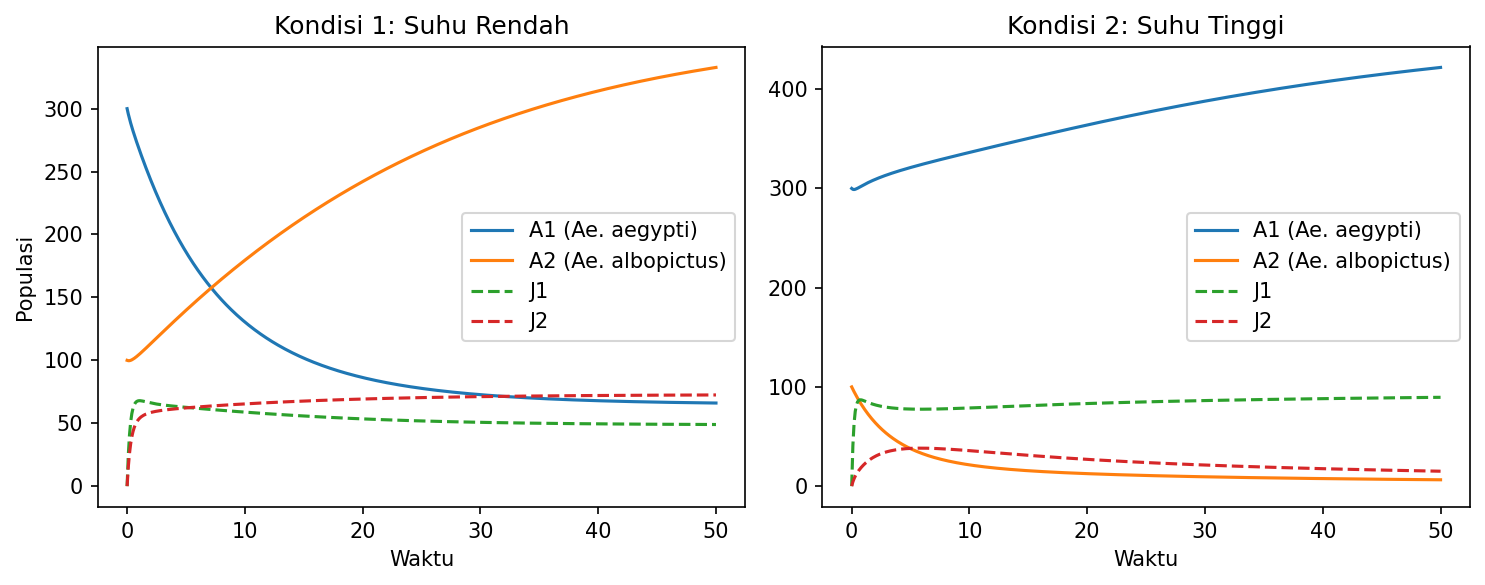

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

plt.rcParams['figure.dpi'] = 150

# ====================================
# MODEL ODE
# ====================================

def model(y, t, f1, d1, mu1, f2, d2, mu2, a11, a22, a12, a21):

    J1, A1, J2, A2 = y

    dJ1dt = f1*A1*(1 - a11*J1 - a12*J2) - d1*J1
    dA1dt = d1*J1 - mu1*A1

    dJ2dt = f2*A2*(1 - a22*J2 - a21*J1) - d2*J2
    dA2dt = d2*J2 - mu2*A2

    return [dJ1dt, dA1dt, dJ2dt, dA2dt]


# ====================================
# PARAMETER KOMPETISI
# ====================================

alpha11 = 0.01
alpha22 = 0.01
alpha12 = 0.005
alpha21 = 0.005


# ====================================
# KONDISI AWAL
# ====================================

J10 = 0
A10 = 300
J20 = 0
A20 = 100

y0 = [J10, A10, J20, A20]


# ====================================
# WAKTU SIMULASI
# ====================================

t = np.linspace(0, 50, 500)


# ====================================
# KONDISI 1 : SUHU RENDAH
# ====================================

f1, d1, mu1 = 1.0, 0.20, 0.15
f2, d2, mu2 = 1.8, 0.25, 0.05

sol1 = odeint(model, y0, t, args=(f1,d1,mu1,f2,d2,mu2,alpha11,alpha22,alpha12,alpha21))

J1_1, A1_1, J2_1, A2_1 = sol1.T


# ====================================
# KONDISI 2 : SUHU TINGGI
# ====================================

f1, d1, mu1 = 1.8, 0.25, 0.05
f2, d2, mu2 = 0.5, 0.10, 0.25

sol2 = odeint(model, y0, t, args=(f1,d1,mu1,f2,d2,mu2,alpha11,alpha22,alpha12,alpha21))

J1_2, A1_2, J2_2, A2_2 = sol2.T


# ====================================
# PLOT HASIL
# ====================================

fig, ax = plt.subplots(1,2, figsize=(10,4))

# suhu rendah
ax[0].plot(t, A1_1, label="A1 (Ae. aegypti)")
ax[0].plot(t, A2_1, label="A2 (Ae. albopictus)")
ax[0].plot(t, J1_1, '--', label="J1")
ax[0].plot(t, J2_1, '--', label="J2")

ax[0].set_title("Kondisi 1: Suhu Rendah")
ax[0].set_xlabel("Waktu")
ax[0].set_ylabel("Populasi")
ax[0].legend()


# suhu tinggi
ax[1].plot(t, A1_2, label="A1 (Ae. aegypti)")
ax[1].plot(t, A2_2, label="A2 (Ae. albopictus)")
ax[1].plot(t, J1_2, '--', label="J1")
ax[1].plot(t, J2_2, '--', label="J2")

ax[1].set_title("Kondisi 2: Suhu Tinggi")
ax[1].set_xlabel("Waktu")
ax[1].legend()

plt.tight_layout()
plt.show()

## Analisis Hasil Simulasi (Tugas A Nomor 2)

Model dinamika populasi dua spesies nyamuk diberikan oleh sistem ODE berikut

$$
\frac{dJ_1}{dt}=f_1A_1(1-\alpha_{11}J_1-\alpha_{12}J_2)-d_1J_1
$$

$$
\frac{dA_1}{dt}=d_1J_1-\mu_1A_1
$$

$$
\frac{dJ_2}{dt}=f_2A_2(1-\alpha_{22}J_2-\alpha_{21}J_1)-d_2J_2
$$

$$
\frac{dA_2}{dt}=d_2J_2-\mu_2A_2
$$

dengan:

* $J_i$ : populasi juvenil spesies $i$
* $A_i$ : populasi dewasa spesies $i$
* $f_i$ : laju fekunditas
* $d_i$ : laju perkembangan juvenil ke dewasa
* $\mu_i$ : laju kematian dewasa
* $\alpha_{ij}$ : koefisien kompetisi

Kompetisi antar spesies terjadi pada fase juvenil melalui faktor

$$
(1-\alpha_{ii}J_i-\alpha_{ij}J_j)
$$

yang merepresentasikan keterbatasan sumber daya di habitat larva.

---

# Kondisi 1 : Suhu Rendah

Parameter yang digunakan adalah

| Parameter | Ae. aegypti | Ae. albopictus |
|----------|-------------|---------------|
| $f$ | 1.0 | 1.8 |
| $d$ | 0.20 | 0.25 |
| $\mu$ | 0.15 | 0.05 |

Koefisien kompetisi

$$
\alpha_{11}=\alpha_{22}=0.01, \qquad
\alpha_{12}=\alpha_{21}=0.005
$$

Kondisi awal simulasi

$$
A_1(0)=300,\quad A_2(0)=100,\quad J_1(0)=0,\quad J_2(0)=0
$$

Hasil simulasi numerik hingga $t=50$ menghasilkan nilai populasi mendekati

| Variabel | Nilai Awal | Nilai Akhir |
|---------|-----------|-------------|
| $A_1$ | 300 | $\approx 70$ |
| $A_2$ | 100 | $\approx 330$ |
| $J_1$ | 0 | $\approx 50$ |
| $J_2$ | 0 | $\approx 70$ |

Interpretasi biologis:

Pada suhu rendah spesies **Ae. albopictus** memiliki keunggulan kompetitif karena

* laju reproduksi lebih tinggi ($f_2>f_1$)
* laju perkembangan juvenil lebih cepat ($d_2>d_1$)
* mortalitas dewasa lebih rendah ($\mu_2<\mu_1$)

Akibatnya populasi **Ae. albopictus meningkat secara signifikan**, sedangkan populasi **Ae. aegypti menurun namun tidak mencapai nol**.

Dengan demikian **tidak terjadi kepunahan**, tetapi terjadi **dominasi kompetitif Ae. albopictus**.

---

# Kondisi 2 : Suhu Tinggi

Parameter yang digunakan adalah

| Parameter | Ae. aegypti | Ae. albopictus |
|----------|-------------|---------------|
| $f$ | 1.8 | 0.5 |
| $d$ | 0.25 | 0.10 |
| $\mu$ | 0.05 | 0.25 |

Hasil simulasi numerik pada $t=50$ menunjukkan

| Variabel | Nilai Awal | Nilai Akhir |
|---------|-----------|-------------|
| $A_1$ | 300 | $\approx 420$ |
| $A_2$ | 100 | $\approx 10$ |
| $J_1$ | 0 | $\approx 90$ |
| $J_2$ | 0 | $\approx 15$ |

Interpretasi biologis:

Pada suhu tinggi spesies **Ae. aegypti** memperoleh keuntungan ekologis karena

* laju fekunditas meningkat ($f_1$ tinggi)
* mortalitas dewasa rendah ($\mu_1$ kecil)
* perkembangan juvenil lebih cepat ($d_1>d_2$)

Sebaliknya **Ae. albopictus** mengalami kondisi yang tidak menguntungkan karena

* laju reproduksi rendah
* mortalitas dewasa tinggi

Akibatnya populasi **Ae. albopictus menurun drastis dan mendekati nol**.

Dengan demikian pada kondisi suhu tinggi terjadi **competitive exclusion**, di mana **Ae. aegypti mendominasi ekosistem dan Ae. albopictus menuju kepunahan**.

---

# Kesimpulan

Perubahan suhu lingkungan mempengaruhi parameter biologis yang menentukan hasil kompetisi antar spesies.

* Pada **suhu rendah**, *Ae. albopictus* menjadi spesies dominan.
* Pada **suhu tinggi**, *Ae. aegypti* menjadi spesies dominan dan *Ae. albopictus* mengalami kepunahan.

Hasil ini menunjukkan bahwa faktor lingkungan seperti suhu dapat mengubah struktur komunitas vektor penyakit secara signifikan.

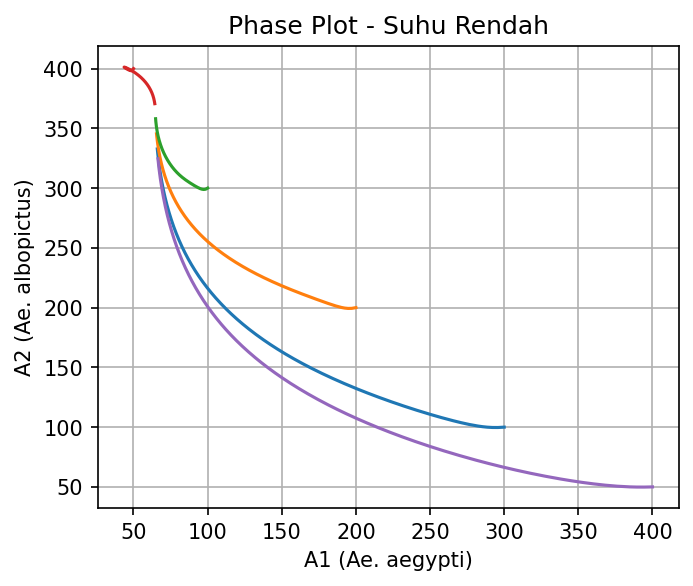

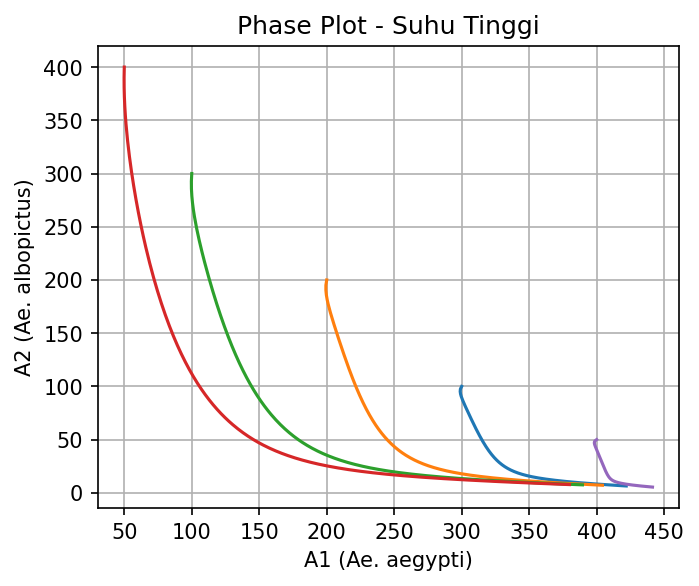

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

plt.rcParams['figure.dpi'] = 150

# ==============================
# MODEL ODE
# ==============================
def model(y, t, f1, d1, mu1, f2, d2, mu2, a11, a22, a12, a21):
    J1, A1, J2, A2 = y

    dJ1dt = f1*A1*(1 - a11*J1 - a12*J2) - d1*J1
    dA1dt = d1*J1 - mu1*A1

    dJ2dt = f2*A2*(1 - a22*J2 - a21*J1) - d2*J2
    dA2dt = d2*J2 - mu2*A2

    return [dJ1dt, dA1dt, dJ2dt, dA2dt]

# ==============================
# PARAMETER KOMPETISI
# ==============================
alpha11 = 0.01
alpha22 = 0.01
alpha12 = 0.005
alpha21 = 0.005

# ==============================
# WAKTU SIMULASI
# ==============================
t = np.linspace(0,50,500)

# ==============================
# VARIASI KONDISI AWAL (A1,A2)
# ==============================
initial_conditions = [
    (300,100),
    (200,200),
    (100,300),
    (50,400),
    (400,50)
]

# ==============================
# KONDISI 1 : SUHU RENDAH
# ==============================
f1,d1,mu1 = 1.0,0.20,0.15
f2,d2,mu2 = 1.8,0.25,0.05

plt.figure(figsize=(5,4))

for A10,A20 in initial_conditions:

    y0 = [0, A10, 0, A20]

    sol = odeint(model, y0, t, args=(f1,d1,mu1,f2,d2,mu2,
                                    alpha11,alpha22,alpha12,alpha21))

    J1,A1,J2,A2 = sol.T

    plt.plot(A1,A2)

plt.xlabel("A1 (Ae. aegypti)")
plt.ylabel("A2 (Ae. albopictus)")
plt.title("Phase Plot - Suhu Rendah")
plt.grid(True)
plt.show()


# ==============================
# KONDISI 2 : SUHU TINGGI
# ==============================
f1,d1,mu1 = 1.8,0.25,0.05
f2,d2,mu2 = 0.5,0.10,0.25

plt.figure(figsize=(5,4))

for A10,A20 in initial_conditions:

    y0 = [0, A10, 0, A20]

    sol = odeint(model, y0, t, args=(f1,d1,mu1,f2,d2,mu2,
                                    alpha11,alpha22,alpha12,alpha21))

    J1,A1,J2,A2 = sol.T

    plt.plot(A1,A2)

plt.xlabel("A1 (Ae. aegypti)")
plt.ylabel("A2 (Ae. albopictus)")
plt.title("Phase Plot - Suhu Tinggi")
plt.grid(True)
plt.show()

## Analisis Phase Plot (Tugas A Nomor 3)

Untuk memahami dinamika kompetisi antara *Aedes aegypti* dan *Aedes albopictus*, dilakukan analisis pada bidang fase dengan memplot lintasan solusi dalam bidang $(A_1,A_2)$.

Setiap lintasan merepresentasikan solusi sistem ODE

$$
\frac{dJ_1}{dt}=f_1A_1(1-\alpha_{11}J_1-\alpha_{12}J_2)-d_1J_1
$$

$$
\frac{dA_1}{dt}=d_1J_1-\mu_1A_1
$$

$$
\frac{dJ_2}{dt}=f_2A_2(1-\alpha_{22}J_2-\alpha_{21}J_1)-d_2J_2
$$

$$
\frac{dA_2}{dt}=d_2J_2-\mu_2A_2
$$

dengan berbagai kondisi awal populasi dewasa $(A_1(0),A_2(0))$.  
Populasi juvenil diasumsikan $J_1(0)=J_2(0)=0$.

Lintasan yang dihasilkan menggambarkan bagaimana pasangan populasi $(A_1(t),A_2(t))$ berkembang terhadap waktu.

---

# Kondisi 1 : Suhu Rendah

Pada kondisi suhu rendah digunakan parameter

$$
f_1=1.0, \quad d_1=0.20, \quad \mu_1=0.15
$$

$$
f_2=1.8, \quad d_2=0.25, \quad \mu_2=0.05
$$

Hasil phase plot menunjukkan bahwa lintasan dari berbagai kondisi awal cenderung menuju suatu titik keseimbangan interior

$$
(A_1^*,A_2^*)
$$

dengan

$$
A_2^* > A_1^*
$$

Hal ini menunjukkan bahwa kedua spesies dapat **koeksis** dalam jangka panjang, tetapi populasi *Ae. albopictus* lebih dominan dibandingkan *Ae. aegypti*.

Dominasi ini disebabkan oleh parameter biologis yang lebih menguntungkan bagi *Ae. albopictus*, yaitu:

* laju fekunditas lebih tinggi $(f_2 > f_1)$
* perkembangan juvenil lebih cepat $(d_2 > d_1)$
* mortalitas dewasa lebih rendah $(\mu_2 < \mu_1)$

Akibatnya populasi *Ae. albopictus* mencapai tingkat keseimbangan yang lebih tinggi.

---

# Kondisi 2 : Suhu Tinggi

Pada kondisi suhu tinggi parameter berubah menjadi

$$
f_1=1.8, \quad d_1=0.25, \quad \mu_1=0.05
$$

$$
f_2=0.5, \quad d_2=0.10, \quad \mu_2=0.25
$$

Phase plot menunjukkan bahwa seluruh lintasan dari berbagai kondisi awal bergerak menuju keadaan

$$
A_2 \rightarrow 0
$$

sementara

$$
A_1 > 0
$$

Hal ini menunjukkan terjadinya **competitive exclusion**, di mana spesies *Ae. aegypti* mendominasi sistem dan *Ae. albopictus* mengalami kepunahan.

Keadaan ini disebabkan oleh parameter entomologis yang menguntungkan bagi *Ae. aegypti*, yaitu:

* fekunditas tinggi $(f_1 > f_2)$
* perkembangan juvenil lebih cepat $(d_1 > d_2)$
* mortalitas dewasa lebih rendah $(\mu_1 < \mu_2)$

Sebaliknya *Ae. albopictus* memiliki tingkat reproduksi rendah dan mortalitas dewasa yang tinggi sehingga tidak mampu mempertahankan populasinya.

---

# Kesimpulan Dinamika Sistem

Dari phase plot dapat disimpulkan bahwa perubahan kondisi lingkungan (suhu) dapat mengubah struktur kompetisi antar spesies:

* Pada **suhu rendah**, sistem memiliki titik keseimbangan koeksistensi dengan dominasi *Ae. albopictus*.
* Pada **suhu tinggi**, sistem menuju keadaan **dominasi tunggal oleh *Ae. aegypti*** dan kepunahan *Ae. albopictus*.

Lintasan dari berbagai kondisi awal yang menuju titik keseimbangan yang sama menunjukkan bahwa titik tersebut merupakan **attractor stabil** bagi sistem dinamika populasi.

# Bagian B
Selain iklim, ketersediaan nutrisi di genangan air menentukan koefisien kompetisi ($\alpha$). Makanan kualitas rendah (seperti serasah daun kering) membuat larva Ae. albopictus jauh lebih superior dalam menyerap nutrisi. Makanan kualitas tinggi (seperti bangkai serangga dan rumput membusuk) menurunkan persaingan sehingga Ae. aegypti memiliki peluang bertahan.

Asumsikan suhu lingkungan mendukung bagi kedua nyamuk, sehingga parameter entomologis mereka identik.
$f_1 = f_2 = 1.0$, $d_1 = d_2 = 0.2$, dan $\mu_1 = \mu_2 = 0.1$.

## **Skenario 1: Makanan Kualitas Rendah**
Gunakan parameter: $\alpha_{11} = 1/60$, $\alpha_{22} = 1/60$, $\alpha_{12} = 1/40$, $\alpha_{21} = 1/180$

## **Skenario 2: Makanan Kualitas Tinggi**
$\alpha_{11} = 1/100$, $\alpha_{22} = 1/100$, $\alpha_{12} = 1/200$, $\alpha_{21} = 1/200$

Tugas Anda adalah


1.   Lakukan simulasi untuk kedua skenario makanan ini. Gunakan kondisi awal jumlah nyamuk Ae. aegypti 300, Ae. albopictus 100, dan juvenil 0. Plot grafik populasinya.
2.   Analisis populasi masing-masing jenis nyamuk di lingkungan makanan kualitas rendah vs kualitas tinggi! Berikan interpretasi yang jelas!



## **Jawab:**

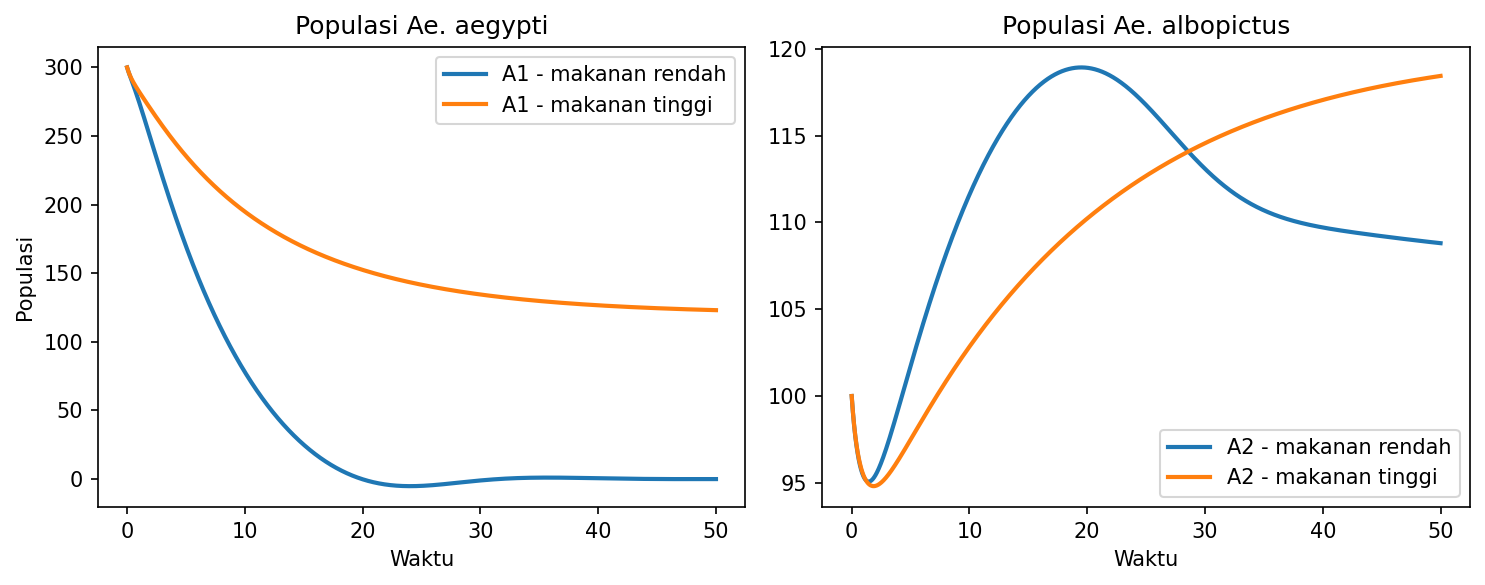

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

plt.rcParams['figure.dpi'] = 150

# ====================================
# MODEL ODE
# ====================================

def model(y,t,f1,d1,mu1,f2,d2,mu2,a11,a22,a12,a21):

    J1,A1,J2,A2 = y

    dJ1 = f1*A1*(1-a11*J1-a12*J2) - d1*J1
    dA1 = d1*J1 - mu1*A1

    dJ2 = f2*A2*(1-a22*J2-a21*J1) - d2*J2
    dA2 = d2*J2 - mu2*A2

    return [dJ1,dA1,dJ2,dA2]


# ====================================
# PARAMETER ENTOMOLOGIS
# ====================================

f1=f2=1
d1=d2=0.2
mu1=mu2=0.1

# kondisi awal
y0=[0,300,0,100]

# waktu
t=np.linspace(0,50,2000)


# ====================================
# SKENARIO 1 : MAKANAN KUALITAS RENDAH
# ====================================

a11=1/60
a22=1/60
a12=1/40
a21=1/180

sol_low=odeint(model,y0,t,args=(f1,d1,mu1,f2,d2,mu2,a11,a22,a12,a21))

J1_low,A1_low,J2_low,A2_low = sol_low.T


# ====================================
# SKENARIO 2 : MAKANAN KUALITAS TINGGI
# ====================================

a11=1/100
a22=1/100
a12=1/200
a21=1/200

sol_high=odeint(model,y0,t,args=(f1,d1,mu1,f2,d2,mu2,a11,a22,a12,a21))

J1_high,A1_high,J2_high,A2_high = sol_high.T

# ====================================
# PLOT KEDUA SKENARIO
# ====================================

fig,ax = plt.subplots(1,2,figsize=(10,4))

# Skenario 1
ax[0].plot(t,A1_low,label="A1 - Skenario 1",lw=2)
ax[0].plot(t,A2_low,label="A1 - Skenario 1",lw=2)
ax[0].plot(t,J1_low,label="J1 - Skenario 1",lw=2)
ax[0].plot(t,J2_low,label="J2 - Skenario 1",lw=2)
ax[0].set_title("Populasi Ae. aegypti")
ax[0].set_xlabel("Waktu")
ax[0].set_ylabel("Populasi")
ax[0].legend()

# Skenario 2
ax[0].plot(t,A1_high,label="A1 - Skenario 1",lw=2)
ax[0].plot(t,A2_high,label="A1 - Skenario 1",lw=2)
ax[0].plot(t,J1_high,label="J1 - Skenario 1",lw=2)
ax[0].plot(t,J2_high,label="J2 - Skenario 1",lw=2)
ax[0].set_title("Populasi Ae. aegypti")
ax[0].set_xlabel("Waktu")
ax[0].set_ylabel("Populasi")
ax[0].legend()

plt.tight_layout()
plt.show()

# ====================================
# PLOT PERBANDINGAN
# ====================================

fig,ax = plt.subplots(1,2,figsize=(10,4))

# A1 comparison
ax[0].plot(t,A1_low,label="A1 - makanan rendah",lw=2)
ax[0].plot(t,A1_high,label="A1 - makanan tinggi",lw=2)
ax[0].set_title("Populasi Ae. aegypti")
ax[0].set_xlabel("Waktu")
ax[0].set_ylabel("Populasi")
ax[0].legend()


# A2 comparison
ax[1].plot(t,A2_low,label="A2 - makanan rendah",lw=2)
ax[1].plot(t,A2_high,label="A2 - makanan tinggi",lw=2)
ax[1].set_title("Populasi Ae. albopictus")
ax[1].set_xlabel("Waktu")
ax[1].legend()

plt.tight_layout()
plt.show()

## Analisis dan Interpretasi Hasil Simulasi (Bagian B Nomor 2)

Pada bagian ini dianalisis pengaruh kualitas nutrisi pada habitat larva terhadap dinamika kompetisi antara *Aedes aegypti* dan *Aedes albopictus*. Berbeda dengan Bagian A, pada skenario ini parameter entomologis kedua spesies diasumsikan identik, yaitu

$$
f_1=f_2=1.0, \quad d_1=d_2=0.2, \quad \mu_1=\mu_2=0.1
$$

Dengan demikian perbedaan dinamika populasi hanya ditentukan oleh koefisien kompetisi $\alpha_{ij}$ yang menggambarkan pengaruh kompetisi antar larva dalam memanfaatkan sumber nutrisi.

---

# Skenario 1 : Makanan Kualitas Rendah

Pada kondisi nutrisi rendah digunakan parameter kompetisi

$$
\alpha_{11}=\frac{1}{60}, \quad \alpha_{22}=\frac{1}{60}
$$

$$
\alpha_{12}=\frac{1}{40}, \quad \alpha_{21}=\frac{1}{180}
$$

Karena

$$
\alpha_{12} > \alpha_{21}
$$

maka larva *Ae. aegypti* lebih terpengaruh oleh keberadaan *Ae. albopictus* dibandingkan sebaliknya.

Hasil simulasi menunjukkan bahwa populasi *Ae. aegypti* $(A_1)$ menurun secara signifikan hingga mendekati nol, sedangkan populasi *Ae. albopictus* $(A_2)$ meningkat dan kemudian mencapai keadaan stabil sekitar 108–110 individu.

Secara biologis hal ini menunjukkan bahwa pada kondisi nutrisi rendah, *Ae. albopictus* memiliki kemampuan yang lebih baik dalam memanfaatkan sumber nutrisi larva. Akibatnya spesies ini mampu mendominasi habitat tersebut dan menekan populasi *Ae. aegypti*. Fenomena ini dikenal sebagai **competitive exclusion**, yaitu kondisi ketika satu spesies mengeliminasi spesies lain melalui kompetisi sumber daya.

---

# Skenario 2 : Makanan Kualitas Tinggi

Pada kondisi nutrisi tinggi digunakan parameter kompetisi

$$
\alpha_{11}=\frac{1}{100}, \quad \alpha_{22}=\frac{1}{100}
$$

$$
\alpha_{12}=\frac{1}{200}, \quad \alpha_{21}=\frac{1}{200}
$$

Nilai koefisien kompetisi yang lebih kecil menunjukkan bahwa tekanan kompetisi antar larva menjadi lebih lemah karena sumber nutrisi lebih melimpah.

Hasil simulasi menunjukkan bahwa populasi *Ae. aegypti* menurun dari kondisi awal tetapi kemudian stabil sekitar 120 individu, sedangkan populasi *Ae. albopictus* meningkat secara bertahap hingga mencapai nilai stabil sekitar 118 individu.

Hal ini menunjukkan bahwa pada kondisi nutrisi tinggi kedua spesies mampu bertahan dalam jangka panjang sehingga terjadi **koeksistensi stabil** antara *Ae. aegypti* dan *Ae. albopictus*. Ketersediaan nutrisi yang lebih baik mengurangi intensitas kompetisi sehingga kedua spesies dapat berbagi sumber daya tanpa menyebabkan kepunahan salah satu spesies.

---

# Kesimpulan

Hasil simulasi menunjukkan bahwa kualitas nutrisi pada habitat larva memiliki pengaruh penting terhadap hasil kompetisi antar spesies nyamuk.

* Pada **makanan kualitas rendah**, *Ae. albopictus* lebih unggul dalam kompetisi sehingga populasi *Ae. aegypti* menurun drastis.
* Pada **makanan kualitas tinggi**, kompetisi antar larva menjadi lebih lemah sehingga kedua spesies dapat **koeksis secara stabil**.

Temuan ini menunjukkan bahwa faktor lingkungan seperti ketersediaan nutrisi dapat menentukan struktur komunitas vektor penyakit dalam suatu ekosistem.